# 1.Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# 2.Download NLTK Resources

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\deept\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\deept\AppData\Roaming\nltk_data...


True

# 3.Loading Dataset

In [4]:
df = pd.read_csv("customer_support_tickets.csv")

# 4.Explore Dataset

In [6]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [7]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

# 5.Keeping Important Columns

In [11]:
df = df[['Ticket Description', 'Ticket Type', 'Ticket Priority']]

df.dropna(inplace=True)

df.head()

,Ticket Description,Ticket Type,Ticket Priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


# 6.Text Cleaning & Preprocessing

In [12]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = text.strip()

    # Tokenization
    words = text.split()

    # Remove stopwords + Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [13]:
df['cleaned_text'] = df['Ticket Description'].apply(clean_text)

print(df[['Ticket Description', 'cleaned_text']].head())

                                  Ticket Description  \
0  I'm having an issue with the {product_purchase...   
1  I'm having an issue with the {product_purchase...   
2  I'm facing a problem with my {product_purchase...   
3  I'm having an issue with the {product_purchase...   
4  I'm having an issue with the {product_purchase...   

                                        cleaned_text  
0  im issue productpurchased please assist billin...  
1  im issue productpurchased please assist need c...  
2  im facing problem productpurchased productpurc...  
3  im issue productpurchased please assist proble...  
4  im issue productpurchased please assist note s...  


# 7.Feature Extraction using TF-IDF

In [14]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_text'])

# 8.Prepare Target Variables

## Category Prediction

In [16]:
y_category = df['Ticket Type']

## Priority Prediction

In [17]:
y_priority = df['Ticket Priority']

# 9.Train-Test Split

In [18]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X,
    y_category,
    test_size=0.2,
    random_state=42
)

X_train_pri, X_test_pri, y_train_pri, y_test_pri = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42
)

# 10.Train Category Classification Model

In [19]:
category_model = LogisticRegression(max_iter=1000)

category_model.fit(X_train_cat, y_train_cat)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# 11.Predict Categories

In [20]:
category_predictions = category_model.predict(X_test_cat)

# 12.Evaluate Category Model

In [21]:
print("CATEGORY CLASSIFICATION RESULTS\n")

print("Accuracy:",
      accuracy_score(y_test_cat, category_predictions))

print("\nClassification Report:\n")

print(classification_report(
    y_test_cat,
    category_predictions
))

CATEGORY CLASSIFICATION RESULTS

Accuracy: 0.19657615112160567

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.15      0.10      0.12       357
Cancellation request       0.20      0.21      0.20       327
     Product inquiry       0.17      0.17      0.17       316
      Refund request       0.21      0.25      0.23       345
     Technical issue       0.23      0.25      0.24       349

            accuracy                           0.20      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.19      0.20      0.19      1694



# 13.Confusion Matrix

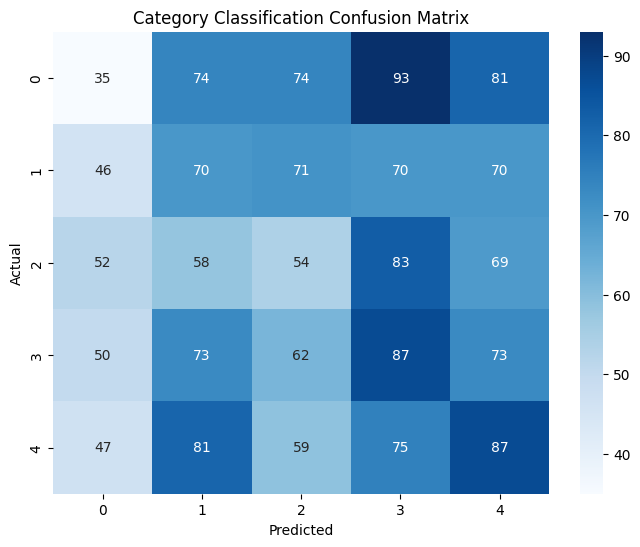

In [22]:
cm = confusion_matrix(y_test_cat, category_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Category Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 14.Train Priority Prediction Model

In [23]:
priority_model = LogisticRegression(max_iter=1000)

priority_model.fit(X_train_pri, y_train_pri)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# 15.Predict Priority

In [24]:
priority_predictions = priority_model.predict(X_test_pri)

# 16.Evaluate Priority Model

In [25]:
print("PRIORITY PREDICTION RESULTS\n")

print("Accuracy:",
      accuracy_score(y_test_pri, priority_predictions))

print("\nClassification Report:\n")

print(classification_report(
    y_test_pri,
    priority_predictions
))

PRIORITY PREDICTION RESULTS

Accuracy: 0.25737898465171194

Classification Report:

              precision    recall  f1-score   support

    Critical       0.24      0.25      0.24       411
        High       0.27      0.28      0.28       409
         Low       0.24      0.24      0.24       415
      Medium       0.28      0.26      0.27       459

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26      1694
weighted avg       0.26      0.26      0.26      1694



# 17.Test on New Ticket

In [27]:
sample_ticket = """
My payment was deducted twice and I still cannot access premium services.
"""

# Clean text
cleaned = clean_text(sample_ticket)

# Convert to vector
vectorized = tfidf.transform([cleaned])

# Predict category
predicted_category = category_model.predict(vectorized)

# Predict priority
predicted_priority = priority_model.predict(vectorized)

print("Predicted Category:", predicted_category[0])

print("Predicted Priority:", predicted_priority[0])

Predicted Category: Cancellation request
Predicted Priority: High


# 18.Save Models

In [29]:
joblib.dump(category_model, "models/category_model.pkl")

joblib.dump(priority_model, "models/priority_model.pkl")

joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

['models/tfidf_vectorizer.pkl']

# 19.Business Explanation